# SSGP

Port of GPJax's implementation: https://docs.jaxgaussianprocesses.com/_examples/uncollapsed_vi/

From this paper: https://arxiv.org/abs/1309.6835

In [1]:
import pymc_extras as pmx

import matplotlib.pyplot as plt
import optax
import numpy as np

import pymc as pm
import pytensor
import pytensor.tensor as pt

# Example data

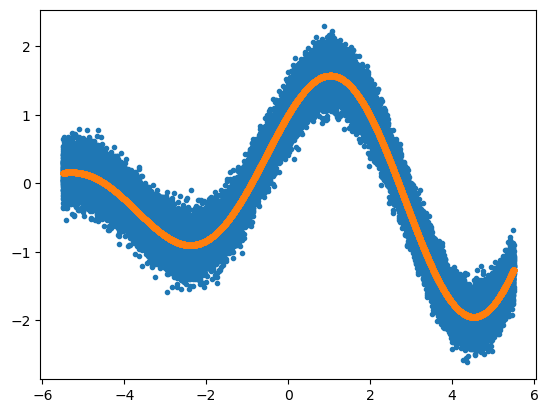

In [2]:
n_data = 50_000
noise = 0.2

low, high = -5.5, 5.5
x = np.sort(np.random.uniform(low, high, n_data))
f = lambda x: np.sin(1 * x) + np.cos(0.75 * x)
signal = f(x)
y = signal + noise * np.random.randn(n_data)

X, y = x[:, None], y[:, None]

plt.plot(x, y, ".")
plt.plot(x, signal, ".");

# Model and fit

In [3]:
with pm.Model() as model:
    eta = pm.Exponential("eta", scale=5.0)
    ell = pm.InverseGamma("ell", mu=1.0, sigma=1.0, initval=0.25)
    cov_func = eta**2 * pm.gp.cov.ExpQuad(1, ls=ell)

    c = pm.Exponential("c", scale=5)
    mean_func = pm.gp.mean.Constant(c)

    n_inducing = 50
    z_init = pm.gp.util.kmeans_inducing_points(n_inducing, np.asarray(X))
    z_init = np.sort(z_init, axis=0)

    sigma = pm.Exponential("sigma", scale=5.0)

    svgp = pmx.gp.WhitenedSVGP(
        mean_func=mean_func,
        cov_func=cov_func,
        sigma=sigma,
        z_init=z_init,
    )

In [4]:
n_steps = 10_000
batch_size = 512

optimizer = optax.adamw(learning_rate=1e-2)

idata = pmx.gp.fit_jax(
    svgp,
    X,
    y,
    optimizer=optimizer,
    n_steps=n_steps,
    batch_size=batch_size,
    model=model,
)

Output()

W0414 09:42:44.053315 3986150 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


In [5]:
idata

Inference data with groups:
	> posterior
	> unconstrained_posterior
	> fit

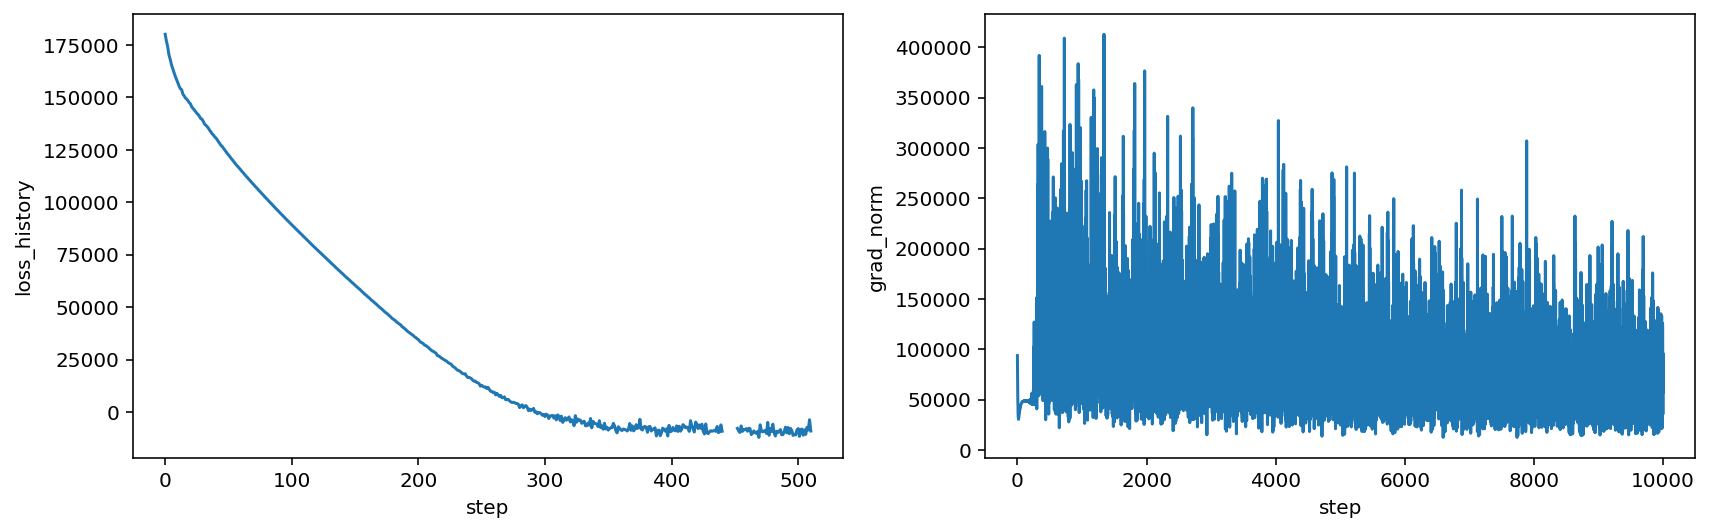

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4), dpi=144)
idata.fit.loss_history.plot(ax=ax[0])
idata.fit.grad_norm.plot(ax=ax[1])

# Prediction

In [7]:
t = np.linspace(-6, 7, 200)[:, None]

with model:
    f_predict = svgp.compile_pred_func(diag=True)

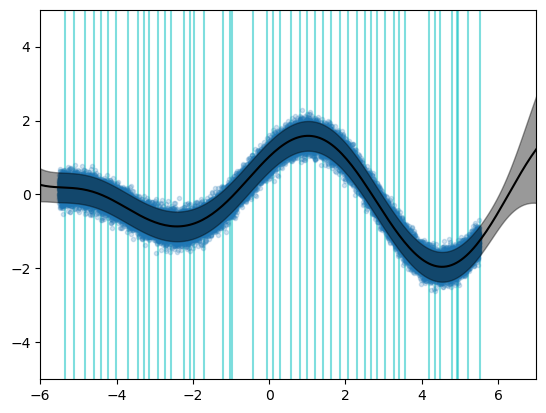

In [8]:
mu, var = f_predict(t, idata)
mu = mu.squeeze()
sd = np.sqrt(var).squeeze()

plt.plot(x, y, ".", zorder=0, alpha=0.2)
plt.plot(t.flatten(), mu, color="k")
plt.fill_between(t.flatten(), mu - 2 * sd, mu + 2 * sd, color="k", alpha=0.4, zorder=1)
plt.xlim([-6, 7])
plt.ylim([-5, 5])

z = idata.fit["inducing_points"].values.flatten()
for z_ in z:
    plt.axvline(x=z_, color="c", zorder=-2, alpha=0.5)

In [9]:
idata = svgp.unwhiten(idata, model=model)
idata

Inference data with groups:
	> posterior
	> unconstrained_posterior
	> fit
	> untransformed_fit

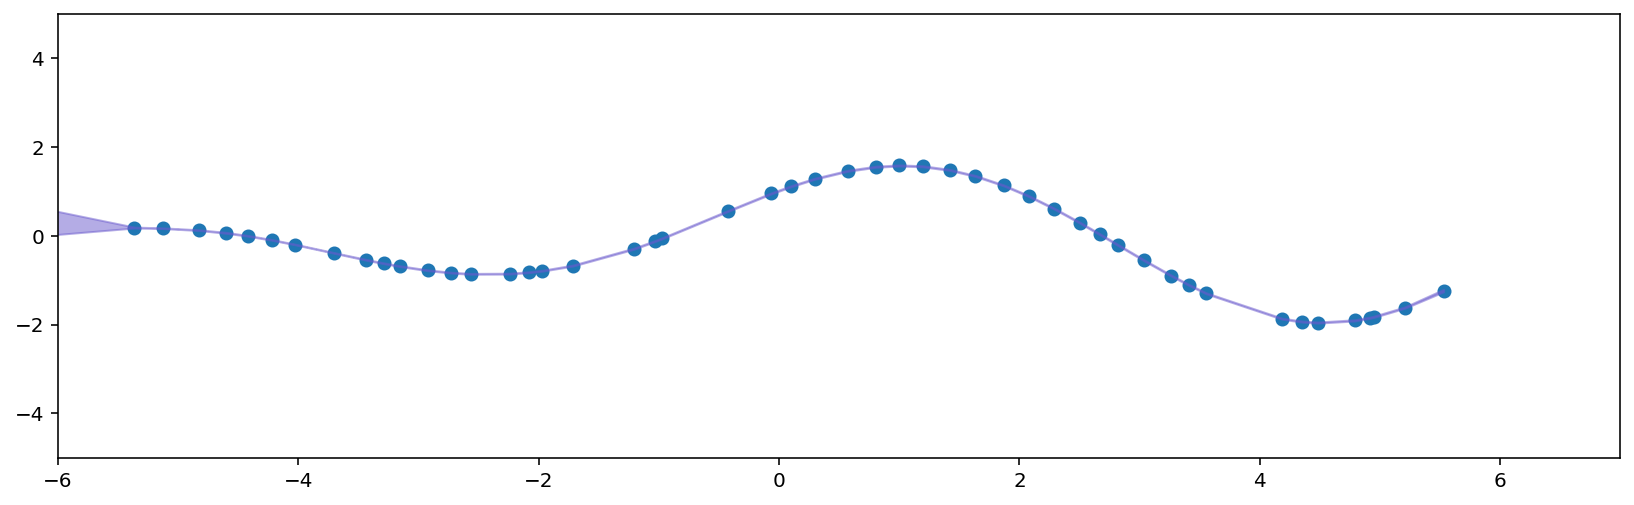

In [10]:
z = idata.fit["inducing_points"].values.squeeze()
order = np.argsort(z)

mu_u = idata.untransformed_fit["inducing_mean"].values[order]
sd_u = idata.untransformed_fit["inducing_std"].values[order]
z = z[order]

fig, ax = plt.subplots(figsize=(14, 4), dpi=144)
ax.scatter(z, mu_u)
ax.fill_between(z, mu_u - 2 * sd_u, mu_u + 2 * sd_u, color="slateblue", alpha=0.5)
ax.set(xlim=[-6, 7], ylim=[-5, 5])
plt.show()

# 2D example

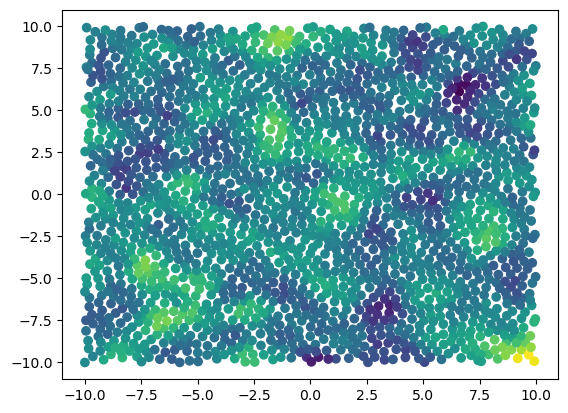

In [11]:
def simulate_2d(
    beta0_true,
    beta1_true,
    ell_true,
    eta_true,
    sigma_true,
):
    seed = sum(map(ord, "hsgp"))
    rng = np.random.default_rng(seed)

    # Create the 2d X locations
    from scipy.stats import qmc

    sampler = qmc.Sobol(d=2, scramble=False, optimization="lloyd")
    X = 20 * sampler.random_base2(m=11) - 10.0

    # Draw one sample from the underlying GP
    n = X.shape[0]
    cov_func = eta_true**2 * pm.gp.cov.Matern52(2, ell_true, active_dims=[0, 1])
    gp_true = pm.MvNormal.dist(mu=np.zeros(n), cov=cov_func(X))
    f_true = pm.draw(gp_true, draws=1, random_seed=rng)

    # Add the fixed effects
    mu = f_true

    # The observed data is the latent function plus a small amount
    # of Gaussian distributed noise.
    noise_dist = pm.Normal.dist(mu=0.0, sigma=sigma_true)
    y_obs = mu + pm.draw(noise_dist, draws=n, random_seed=rng)
    return y_obs[:, None], f_true, mu, X


y_data, f_true, mu, X_data = simulate_2d(1, 1, 1.0, 1.0, 0.1)
plt.scatter(X_data[:, 0], X_data[:, 1], c=y_data);

In [12]:
with pm.Model() as model:
    eta = pm.Exponential("eta", scale=1.0)
    ell = pm.InverseGamma("ell", mu=1.0, sigma=1.0)
    cov_func = eta**2 * pm.gp.cov.ExpQuad(input_dim=2, ls=ell)

    c = pm.Exponential("c", scale=10)
    mean_func = pm.gp.mean.Constant(c)

    n_inducing = 200
    z_init = pm.gp.util.kmeans_inducing_points(n_inducing, np.asarray(X_data))

    sigma = pm.Exponential("sigma", scale=10)

    svgp = pmx.gp.WhitenedSVGP(
        mean_func=mean_func,
        cov_func=cov_func,
        sigma=sigma,
        z_init=z_init,
    )

In [13]:
import pytensor

batch_size = 512

optimizer = optax.adamw(learning_rate=1e-2)

idata = pmx.gp.fit_jax(
    svgp,
    X_data,
    y_data,
    optimizer=optimizer,
    n_steps=n_steps,
    batch_size=batch_size,
    model=model,
    seed=0,
)

Output()

In [18]:
idata

Inference data with groups:
	> posterior
	> unconstrained_posterior
	> fit

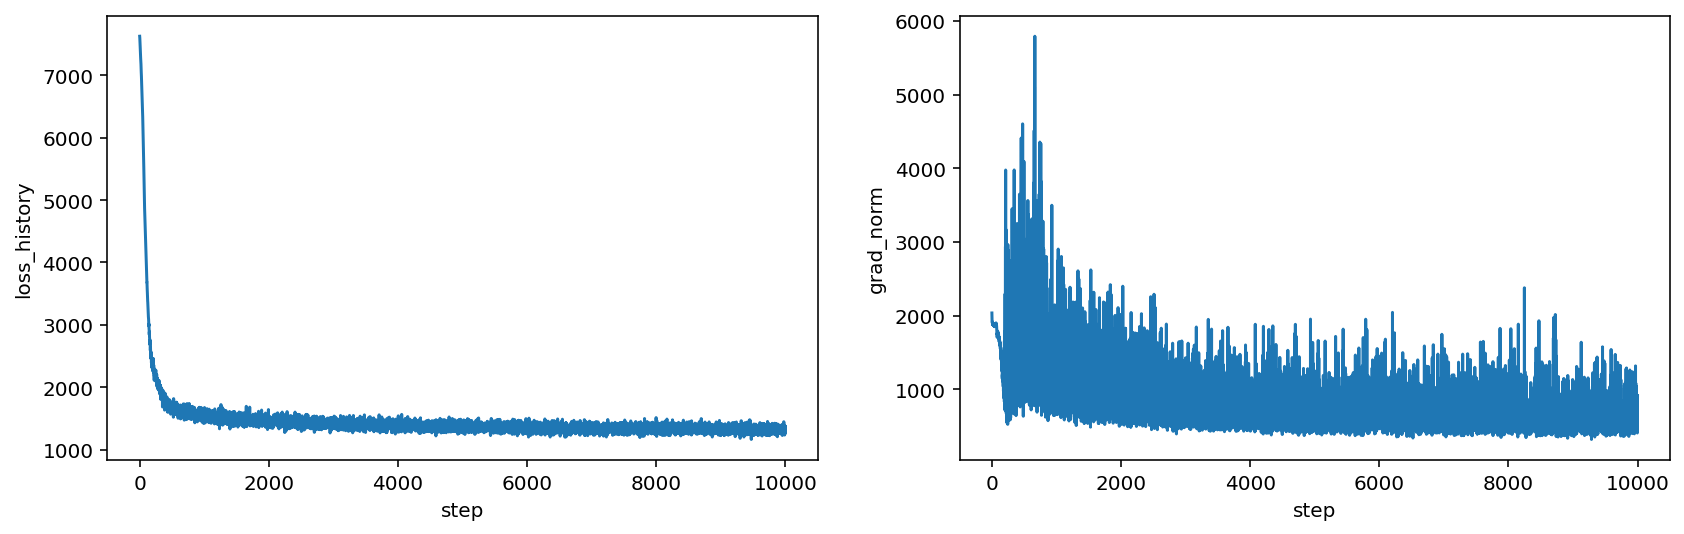

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4), dpi=144)
idata.fit.loss_history.plot(ax=ax[0])
idata.fit.grad_norm.plot(ax=ax[1])

In [15]:
with model:
    f_predict = svgp.compile_pred_func(diag=True)

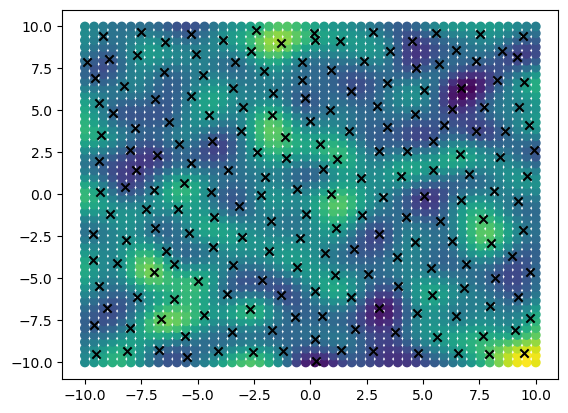

In [16]:
xx1, xx2 = np.meshgrid(np.linspace(-10, 10, 50), np.linspace(-10, 10, 50))
X_pred = np.concatenate((xx1.flatten()[:, None], xx2.flatten()[:, None]), axis=1)


mu, var = f_predict(X_pred, idata)
mu = mu.squeeze()
sd = np.sqrt(var).squeeze()

z = idata.fit["inducing_points"]

plt.scatter(X_pred[:, 0], X_pred[:, 1], c=mu)
plt.scatter(z[:, 0], z[:, 1], marker="x", color="k");

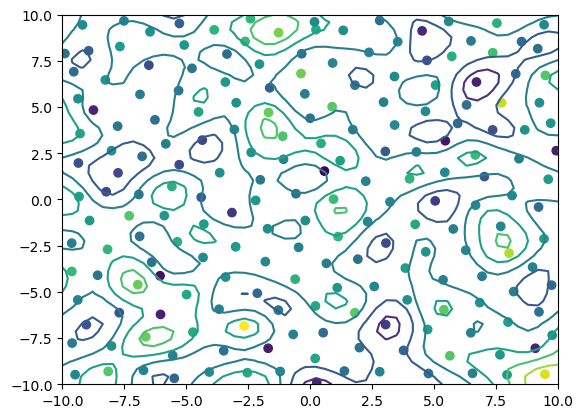

In [17]:
plt.scatter(z[:, 0], z[:, 1], c=idata.fit["variational_mean"])
plt.contour(X_pred[:, 0].reshape(50, 50), X_pred[:, 1].reshape(50, 50), mu.reshape(50, 50));